In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "figure.dpi": 120,
})

In [2]:
BASE = Path(
    "/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results"
)

FIG_DIR = Path.cwd() / "plots" / "heathcote_validation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# From the validation case
chord = 0.10       # [m]
Uinf = 0.30        # [m/s]

# Prescribed root heaving amplitude
a_root = 0.175 * chord

# Reynolds number
Re = 30000

KG_VALUES = {
    "KG1": 0.3,
    "KG2": 0.5,
    "KG3": 0.7,
    "KG4": 0.9,
    "KG5": 1.10,
    "KG6": 1.30,
    "KG7": 1.50,
    "KG8": 1.70,
    "KG9": 1.90,
}

# Structural cases
STRUCTURES = {
    "inflex": "Inflexible",
    "flex": "Flexible",
    # "highflex": "Highly Flexible",
}

print("Base directory:", BASE)
print("Root amplitude:", a_root, "m")

Base directory: /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results
Root amplitude: 0.017499999999999998 m


Reference plots directory

In [3]:
dataset_dir = Path.cwd() / "dataset"

# Iterate over all CSV files in the folder
for file_path in dataset_dir.glob("*.csv"):
    print(f"\n" + "="*50)
    print(f"File Name: {file_path.name}")
    print("="*50)
    
    # Read the dataset
    df = pd.read_csv(file_path)
    
    # Print columns and display top rows
    print("Columns:", df.columns.tolist())
    display(df.head())


File Name: Fig5(b)_HighFlex.csv
Columns: ['0.2986270022883294', ' 11.467661691542276']


,0.2986270022883294,11.467661691542276
0,0.403890,14.950249
1,0.504577,18.606965
2,0.605263,22.437811
3,0.708238,26.616915
4,0.813501,31.318408



File Name: Fif5(a)_HighFlex.csv
Columns: ['0.2998794745088586', ' 1.01046884416054']


,0.2998794745088586,1.01046884416054
0,0.404773,1.039373
1,0.505165,1.082549
2,0.605598,1.136836
3,0.710642,1.205424
4,0.813451,1.285115



File Name: Fig5(a)_Flexible.csv
Columns: ['0.2972665148063781', ' 1.0147757255936678']


...

,-0.002613039939375006,-0.8348115299334808
0,0.066482,-0.103104
1,0.140680,0.667406
2,0.209680,1.304878
3,0.283497,1.698448
4,0.346838,1.748337



File Name: Fig4_Flexible.csv
Columns: ['-0.0029069767441862737', ' 1.484126984126986']


,-0.0029069767441862737,1.484126984126986
0,0.069767,1.636508
1,0.139535,1.496825
2,0.209302,1.071429
3,0.281977,0.385714
4,0.351744,-0.312698



File Name: Fig4_Inflexible.csv
Columns: ['0.004443009907659667', ' 1.1330376940133038']


,0.004443009907659667,1.1330376940133038
0,0.070198,1.066519
1,0.138289,0.805987
2,0.206234,0.401330
3,0.276615,-0.097561
4,0.347040,-0.552106


In [4]:
SWEEP_CASES = {}

for kg_name, kg_value in KG_VALUES.items():
    for struct_key, struct_label in STRUCTURES.items():

        case_name = f"{kg_name}_{struct_key}"

        SWEEP_CASES[case_name] = {
            "path": BASE / f"results_{case_name}",
            "kg": kg_value,
            "structure": struct_key,
            "label": struct_label,
        }


TIPDISP_KG = 1.82

TIPDISP_CASES = {
    "inflex": BASE / "results_tipdisp_inflex",
    "flex": BASE / "results_tipdisp_flex",
    "highflex": BASE / "results_tipdisp_highflex",
}

# Print sweep cases
for name, info in SWEEP_CASES.items():
    print(
        f"{name:20s} "
        f"kG={info['kg']:.2f}  "
        f"{info['structure']:10s}  "
        f"{info['path']}"
    )

KG1_inflex           kG=0.30  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_inflex
KG1_flex             kG=0.30  flex        /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_flex
KG2_inflex           kG=0.50  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_inflex
KG2_flex             kG=0.50  flex        /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_flex
KG3_inflex           kG=0.70  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG3_inflex
KG3_flex             kG=0.70  flex        /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG3_flex
KG4_inflex           kG=0.90  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG4_inflex
KG4_flex             kG=0.90  flex        /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG4_flex
KG5_inflex           kG=1.10  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/

In [5]:
print("SWEEP CASES")
print("-" * 60)

for name, info in SWEEP_CASES.items():
    path = info["path"]

    status = "FOUND" if path.exists() else "MISSING"

    print(f"{status:8s} : {path.name}")

print("\nTIP-DISPLACEMENT CASES")
print("-" * 60)

for structure, path in TIPDISP_CASES.items():

    status = "FOUND" if path.exists() else "MISSING"

    print(f"{status:8s} : {path.name}")

SWEEP CASES
------------------------------------------------------------
FOUND    : results_KG1_inflex
FOUND    : results_KG1_flex
FOUND    : results_KG2_inflex
FOUND    : results_KG2_flex
FOUND    : results_KG3_inflex
FOUND    : results_KG3_flex
FOUND    : results_KG4_inflex
FOUND    : results_KG4_flex
FOUND    : results_KG5_inflex
FOUND    : results_KG5_flex
FOUND    : results_KG6_inflex
FOUND    : results_KG6_flex
FOUND    : results_KG7_inflex
FOUND    : results_KG7_flex
FOUND    : results_KG8_inflex
FOUND    : results_KG8_flex
FOUND    : results_KG9_inflex
FOUND    : results_KG9_flex

TIP-DISPLACEMENT CASES
------------------------------------------------------------
FOUND    : results_tipdisp_inflex
FOUND    : results_tipdisp_flex
FOUND    : results_tipdisp_highflex


In [6]:
def get_solid_diagnostics_path(case_dir):
    """
    Return:
        case_dir/solid/diagnostics/solid_diagnostics.csv
    """
    path = case_dir / "solid" / "diagnostics" / "solid_diagnostics.csv"

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find solid diagnostics:\n{path}"
        )

    return path


def get_coupling_history_path(case_dir):

    path = case_dir / "coupling" / "coupling_history.csv"

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find coupling history:\n{path}"
        )

    return path


def list_fluid_files(case_dir):

    fluid_dir = case_dir / "fluid"

    if not fluid_dir.exists():
        return []

    return sorted(fluid_dir.iterdir())

In [7]:
test_case = SWEEP_CASES["KG1_flex"]["path"]

solid_file = get_solid_diagnostics_path(test_case)

test_df = pd.read_csv(solid_file)

print("File:")
print(solid_file)

print("\nColumns:")
print(test_df.columns.tolist())

print("\nFirst rows:")
display(test_df.head())

File:
/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_flex/solid/diagnostics/solid_diagnostics.csv

Columns:
['Step', 'Time', 'Root_Uz', 'Mid_Uz', 'Tip_Uz', 'Root_Vz', 'Mid_Vz', 'Tip_Vz', 'Root_Az', 'Mid_Az', 'Tip_Az', 'ElasticEnergy', 'KineticEnergy', 'DampingEnergy', 'TotalEnergy', 'DeltaE', 'DeltaE_over_E0', 'FluidWork', 'StructuralWork', 'CumFluidWork', 'CumStructuralWork', 'WorkError', 'NewtonIterations', 'NewtonResidual', 'ForceNorm', 'WallTime']

First rows:


,Step,Time,Root_Uz,Mid_Uz,Tip_Uz,Root_Vz,Mid_Vz,Tip_Vz,Root_Az,Mid_Az,...,DeltaE_over_E0,FluidWork,StructuralWork,CumFluidWork,CumStructuralWork,WorkError,NewtonIterations,NewtonResidual,ForceNorm,WallTime
0,1,0.005,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1,0.000000e+00,0.000000e+00,0.000000
1,2,0.010,9.843349e-09,-3.805034e-10,1.161347e-10,0.000004,-1.509435e-07,4.606994e-08,0.001302,-0.000050,...,434.516132,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2,4.630089e-15,1.967823e-13,32.306798
2,3,0.015,3.936859e-08,-7.360168e-10,7.735064e-10,0.000008,5.339369e-09,2.161017e-07,0.000473,0.000086,...,3048.119124,5.268231e-18,5.269473e-18,5.268231e-18,5.269473e-18,0.000012,2,2.232293e-12,1.778290e-10,7.358863
3,4,0.020,8.856131e-08,4.332819e-09,4.481100e-10,0.000012,2.009066e-06,-3.396937e-07,0.000956,0.000611,...,8499.955807,1.497076e-16,1.497242e-16,1.549759e-16,1.549936e-16,0.000110,2,1.379292e-11,1.100035e-09,0.967557
4,5,0.025,1.573975e-07,2.320029e-08,-1.033189e-08,0.000016,5.534000e-06,-3.951220e-06,0.000717,0.000768,...,17696.854769,1.221338e-15,1.221394e-15,1.376314e-15,1.376388e-15,0.000045,2,4.472893e-11,3.569882e-09,0.958335


In [8]:
def load_displacement(case_dir):

    path = get_solid_diagnostics_path(case_dir)

    df = pd.read_csv(path)

    required = [
        "Time",
        "Root_Uz",
        "Tip_Uz",
    ]

    missing = [
        col for col in required
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing columns {missing} in\n{path}\n"
            f"Available columns:\n{df.columns.tolist()}"
        )

    data = pd.DataFrame({
        "time": df["Time"].to_numpy(dtype=float),
        "root_z": df["Root_Uz"].to_numpy(dtype=float),
        "tip_z": df["Tip_Uz"].to_numpy(dtype=float),
    })

    return data

In [9]:
def kg_to_frequency(kG, Uinf=Uinf, chord=chord):

    f = kG * Uinf / (np.pi * chord)

    return f


def kg_to_period(kG, Uinf=Uinf, chord=chord):

    f = kg_to_frequency(kG, Uinf, chord)

    return 1.0 / f


def kg_to_omega(kG, Uinf=Uinf, chord=chord):

    return 2.0 * np.pi * kg_to_frequency(
        kG,
        Uinf,
        chord
    )


for name, kg in KG_VALUES.items():

    f = kg_to_frequency(kg)
    T = kg_to_period(kg)

    print(
        f"{name}: "
        f"kG={kg:.2f}, "
        f"f={f:.4f} Hz, "
        f"T={T:.4f} s"
    )

KG1: kG=0.30, f=0.2865 Hz, T=3.4907 s
KG2: kG=0.50, f=0.4775 Hz, T=2.0944 s
KG3: kG=0.70, f=0.6685 Hz, T=1.4960 s
KG4: kG=0.90, f=0.8594 Hz, T=1.1636 s
KG5: kG=1.10, f=1.0504 Hz, T=0.9520 s
KG6: kG=1.30, f=1.2414 Hz, T=0.8055 s
KG7: kG=1.50, f=1.4324 Hz, T=0.6981 s
KG8: kG=1.70, f=1.6234 Hz, T=0.6160 s
KG9: kG=1.90, f=1.8144 Hz, T=0.5512 s


In [10]:
def select_last_cycles(time, signal, period, n_cycles=5):

    time = np.asarray(time)
    signal = np.asarray(signal)

    t_end = time[-1]

    available_cycles = (t_end - time[0]) / period

    n_use = min(
        n_cycles,
        int(np.floor(available_cycles))
    )

    if n_use < 1:
        raise ValueError(
            "Simulation does not contain one complete cycle."
        )

    t_start = t_end - n_use * period

    mask = time >= t_start

    return time[mask], signal[mask]

In [11]:
def harmonic_fit(time, signal, omega):

    time = np.asarray(time)
    signal = np.asarray(signal)

    X = np.column_stack([
        np.ones_like(time),
        np.sin(omega * time),
        np.cos(omega * time),
    ])

    coeff, *_ = np.linalg.lstsq(
        X,
        signal,
        rcond=None
    )

    mean = coeff[0]
    C = coeff[1]
    D = coeff[2]

    amplitude = np.sqrt(C**2 + D**2)

    # z = A sin(omega*t + phi)
    phase = np.arctan2(D, C)

    fitted = X @ coeff

    return {
        "mean": mean,
        "amplitude": amplitude,
        "phase_rad": phase,
        "phase_deg": np.degrees(phase),
        "fitted": fitted,
    }

In [12]:
def extract_case_metrics(
    case_dir,
    kG,
    n_cycles=5,
):

    data = load_displacement(case_dir)

    time = data["time"].to_numpy()
    root_z = data["root_z"].to_numpy()
    tip_z = data["tip_z"].to_numpy()

    omega = kg_to_omega(kG)
    period = kg_to_period(kG)

    # Common steady-state window
    t_end = time[-1]

    available_cycles = (
        t_end - time[0]
    ) / period

    n_use = min(
        n_cycles,
        int(np.floor(available_cycles))
    )

    if n_use < 1:
        raise ValueError(
            f"Insufficient simulation duration for {case_dir}"
        )

    t_start = t_end - n_use * period

    mask = time >= t_start

    t_ss = time[mask]
    root_ss = root_z[mask]
    tip_ss = tip_z[mask]

    # Harmonic fits
    root_fit = harmonic_fit(
        t_ss,
        root_ss,
        omega
    )

    tip_fit = harmonic_fit(
        t_ss,
        tip_ss,
        omega
    )

    # Amplitude ratio
    amplitude_ratio = (
        tip_fit["amplitude"]
        /
        root_fit["amplitude"]
    )

    # Phase difference
    phase_diff = (
        tip_fit["phase_deg"]
        -
        root_fit["phase_deg"]
    )

    # Wrap to [-180, 180]
    phase_diff = (
        phase_diff + 180
    ) % 360 - 180

    return {
        "kG": kG,

        "root_amplitude":
            root_fit["amplitude"],

        "tip_amplitude":
            tip_fit["amplitude"],

        "amplitude_ratio":
            amplitude_ratio,

        "root_phase_deg":
            root_fit["phase_deg"],

        "tip_phase_deg":
            tip_fit["phase_deg"],

        "phase_difference_deg":
            phase_diff,

        "n_cycles_used":
            n_use,

        "steady_start_time":
            t_start,

        "steady_end_time":
            t_end,
    }

In [13]:
test_metrics = extract_case_metrics(
    SWEEP_CASES["KG1_flex"]["path"],
    kG=0.3,
    n_cycles=5,
)

test_metrics

{'kG': 0.3,
 'root_amplitude': np.float64(0.012043087041921646),
 'tip_amplitude': np.float64(0.012192055101372426),
 'amplitude_ratio': np.float64(1.0123695908642216),
 'root_phase_deg': np.float64(88.12112540438515),
 'tip_phase_deg': np.float64(88.10366950072512),
 'phase_difference_deg': np.float64(-0.0174559036600499),
 'n_cycles_used': 4,
 'steady_start_time': np.float64(1.0373659840453637),
 'steady_end_time': np.float64(15.0)}

In [14]:
results = []

for case_name, info in SWEEP_CASES.items():

    print(f"Processing {case_name} ...")

    metrics = extract_case_metrics(
        info["path"],
        kG=info["kg"],
        n_cycles=5,
    )

    metrics["case"] = case_name
    metrics["structure"] = info["structure"]
    metrics["structure_label"] = info["label"]

    results.append(metrics)


validation_df = pd.DataFrame(results)

validation_df = validation_df.sort_values(
    ["structure", "kG"]
).reset_index(drop=True)

display(validation_df)

Processing KG1_inflex ...
Processing KG1_flex ...
Processing KG2_inflex ...
Processing KG2_flex ...
Processing KG3_inflex ...
Processing KG3_flex ...
Processing KG4_inflex ...
Processing KG4_flex ...
Processing KG5_inflex ...
Processing KG5_flex ...
Processing KG6_inflex ...
Processing KG6_flex ...
Processing KG7_inflex ...
Processing KG7_flex ...
Processing KG8_inflex ...
Processing KG8_flex ...
Processing KG9_inflex ...
Processing KG9_flex ...


,kG,root_amplitude,tip_amplitude,amplitude_ratio,root_phase_deg,tip_phase_deg,phase_difference_deg,n_cycles_used,steady_start_time,steady_end_time,case,structure,structure_label
0,0.3,0.012043,0.012192,1.012370,88.121125,88.103670,-0.017456,4,1.037366,15.0,KG1_flex,flex,Flexible
1,0.5,0.017366,0.017970,1.034781,89.101858,89.171654,0.069796,5,4.528024,15.0,KG2_flex,flex,Flexible
2,0.7,0.017500,0.018717,1.069566,88.796789,88.931319,0.134531,5,7.520017,15.0,KG3_flex,flex,Flexible
3,0.9,0.017500,0.019575,1.118568,88.453014,88.625125,0.172111,5,9.182236,15.0,KG4_flex,flex,Flexible
4,1.1,0.017500,0.020720,1.184005,88.109239,88.328990,0.219750,5,10.240011,15.0,KG5_flex,flex,Flexible
5,1.3,0.017500,0.022223,1.269898,87.765465,88.005192,0.239728,5,10.972317,15.0,KG6_flex,flex,Flexible
6,1.5,0.017500,0.024191,1.382356,87.421690,87.680151,0.258462,5,11.509341,15.0,KG7_flex,flex,Flexible
7,1.7,0.017500,0.026716,1.526614,87.077915,87.356394,0.278479,5,11.920007,15.0,KG8_flex,flex,Flexible
8,1.9,0.017500,0.030085,1.719144,86.734141,87.055588,0.321447,5,12.244217,15.0,KG9_flex,flex,Flexible
9,0.3,0.012043,0.012062,1.001601,88.121125,88.118993,-0.002133,4,1.037366,15.0,KG1_inflex,inflex,Inflexible


In [15]:
output_csv = (
    FIG_DIR
    / "heathcote_validation_extracted_metrics.csv"
)

validation_df.to_csv(
    output_csv,
    index=False
)

print("Saved:")
print(output_csv)

Saved:
/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/notebooks/plots/heathcote_validation/heathcote_validation_extracted_metrics.csv


In [16]:
amplitude_table = validation_df.pivot(
    index="kG",
    columns="structure_label",
    values="amplitude_ratio"
)

display(amplitude_table)

structure_label,Flexible,Inflexible
kG,,
0.3,1.012370,1.001601
0.5,1.034781,1.004445
0.7,1.069566,1.008725
0.9,1.118568,1.014477
1.1,1.184005,1.021726
1.3,1.269898,1.030520
1.5,1.382356,1.040901
1.7,1.526614,1.052936
1.9,1.719144,1.066714


In [17]:
phase_table = validation_df.pivot(
    index="kG",
    columns="structure_label",
    values="phase_difference_deg"
)

display(phase_table)

structure_label,Flexible,Inflexible
kG,,
0.3,-0.017456,-0.002133
0.5,0.069796,0.009385
0.7,0.134531,0.017804
0.9,0.172111,0.022694
1.1,0.219750,0.027380
1.3,0.239728,0.031444
1.5,0.258462,0.035827
1.7,0.278479,0.039669
1.9,0.321447,0.042220


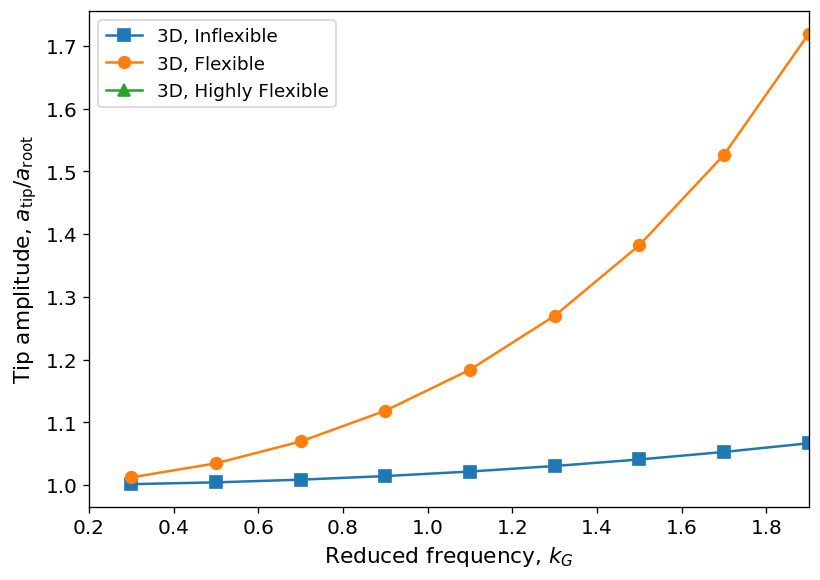

In [18]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

plot_settings = {
    "inflex": {
        "marker": "s",
        "label": "3D, Inflexible",
    },

    "flex": {
        "marker": "o",
        "label": "3D, Flexible",
    },

    "highflex": {
        "marker": "^",
        "label": "3D, Highly Flexible",
    },
}


for structure, settings in plot_settings.items():

    subset = validation_df[
        validation_df["structure"] == structure
    ].sort_values("kG")

    ax.plot(
        subset["kG"],
        subset["amplitude_ratio"],
        marker=settings["marker"],
        markersize=7,
        linewidth=1.5,
        label=settings["label"],
    )


ax.set_xlabel(
    r"Reduced frequency, $k_G$"
)

ax.set_ylabel(
    r"Tip amplitude, $a_{\mathrm{tip}}/a_{\mathrm{root}}$"
)

ax.legend()

ax.set_xlim(0.2, 1.9)

ax.grid(False)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "tip_amplitude_vs_reduced_frequency.pdf",
    bbox_inches="tight"
)

plt.show()

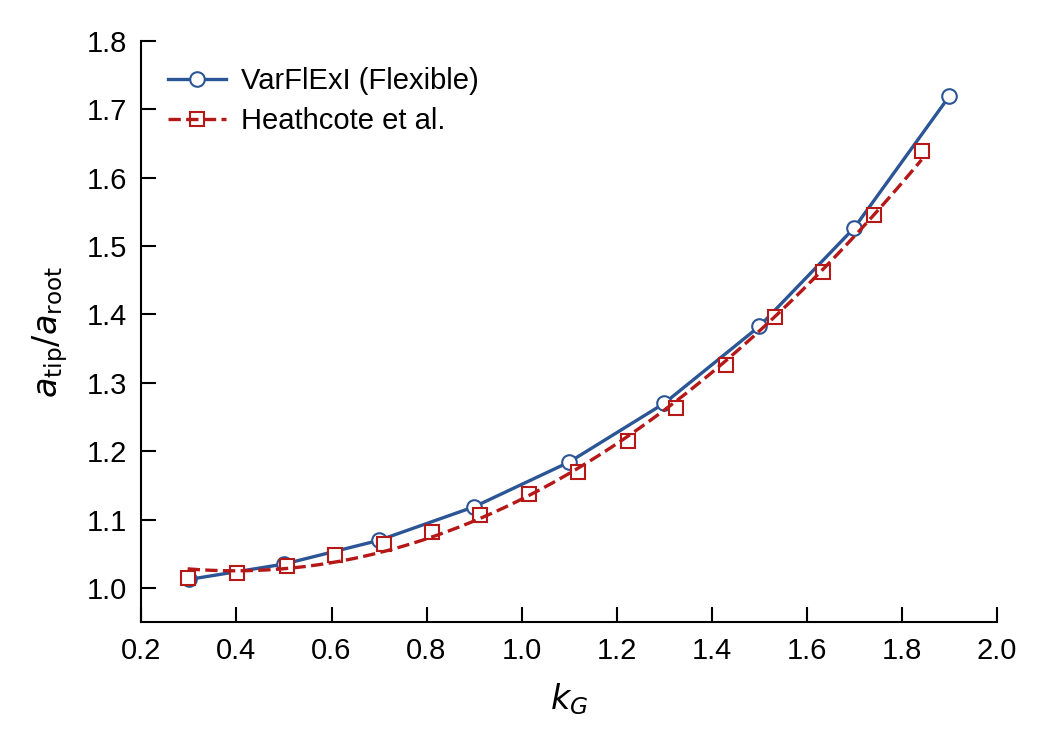

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,            
    "axes.labelsize": 8,       
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,     
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",   
    "ytick.direction": "in",
    "pdf.fonttype": 42,        
    "ps.fonttype": 42
})

# --- Premium Color Palette ---
COLOR_SIM = "#2C5596"  # Deep Charcoal for simulation lines
COLOR_EXP = "#B61717"  # Warm Amber for experimental markers and fit lines

# --- 2. Setup Figure ---
fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

# --- 3. Plotting Simulation Data ---
plot_settings = {
    "flex": {
        "marker": "o",
        "label": "Flexible structure, VarFlExI",
        "color": COLOR_SIM,     
    },
}

for structure, settings in plot_settings.items():
    subset = validation_df[
        validation_df["structure"] == structure
    ].sort_values("kG")

    h_sim, = ax.plot(
        subset["kG"],
        subset["amplitude_ratio"],
        color=settings["color"],
        marker=settings["marker"],
        markersize=3.5,         
        linewidth=0.8,          
        markeredgewidth=0.5,
        markerfacecolor="white",
        label=settings["label"],
    )

# --- 4. Load & Plot Experimental Data ---
exp_filepath = "dataset/Fig5(a)_Flexible.csv"
exp_df = pd.read_csv(exp_filepath, header=None)
exp_df = exp_df.sort_values(by=0)

x_exp = exp_df[0].values
y_exp = exp_df[1].values

# Plot discrete raw points
h_exp_pts, = ax.plot(
    x_exp,
    y_exp,
    color=COLOR_EXP,        
    marker="s",             
    markersize=3.5,
    linewidth=0,            
    linestyle="None",       
    markeredgewidth=0.5,
    markerfacecolor="white",
)

# --- Harmonic Fit Implementation ---
# Harmonic model function reflecting standard sinusoidal extraction: y = A*sin(B*x) + C*cos(B*x) + D
def harmonic_model(x, a, b, c, d):
    return a * np.sin(b * x) + c * np.cos(b * x) + d

h_exp_fit = None
try:
    # Robust initial parameter estimates based on data statistics
    initial_guess = [np.std(y_exp), 1.0, np.std(y_exp), np.mean(y_exp)]
    popt, _ = curve_fit(harmonic_model, x_exp, y_exp, p0=initial_guess, maxfev=10000)
    
    # CRITICAL: Smooth evaluation track limits matched exactly to the dataset domain boundaries
    x_fit = np.linspace(x_exp.min(), x_exp.max(), 500)
    y_fit = harmonic_model(x_fit, *popt)
    
    # Plot smooth harmonic trend curve
    h_exp_fit, = ax.plot(
        x_fit,
        y_fit,
        color=COLOR_EXP,
        linewidth=0.8,
        linestyle="--",
    )
except Exception as e:
    print(f"Harmonic curve fit convergence failed: {e}")

# --- 5. Styling Axes & Unified Legend Arrangement ---
ax.set_xlabel(r"$k_G$")
ax.set_ylabel(r"$a_{\mathrm{tip}}/a_{\mathrm{root}}$")

# Axis padding
ax.set_xlim(0.2, 2.0)
ax.set_ylim(0.95, 1.8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)


legend_handles = [h_sim, (h_exp_pts, h_exp_fit)]
legend_labels = ["VarFlExI (Flexible)", "Heathcote et al."]


ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    frameon=False, 
    loc="upper left",
    handletextpad=0.5,
    labelspacing=0.4
)

# --- 6. Exporting ---
fig.tight_layout()

# Handle path fallback if FIG_DIR is undefined
fig_dir = Path(FIG_DIR) if 'FIG_DIR' in locals() else Path(".")
fig.savefig(
    fig_dir / "tip_amplitude_vs_reduced_frequency.pdf",
    bbox_inches="tight",
    transparent=True 
)

plt.show()


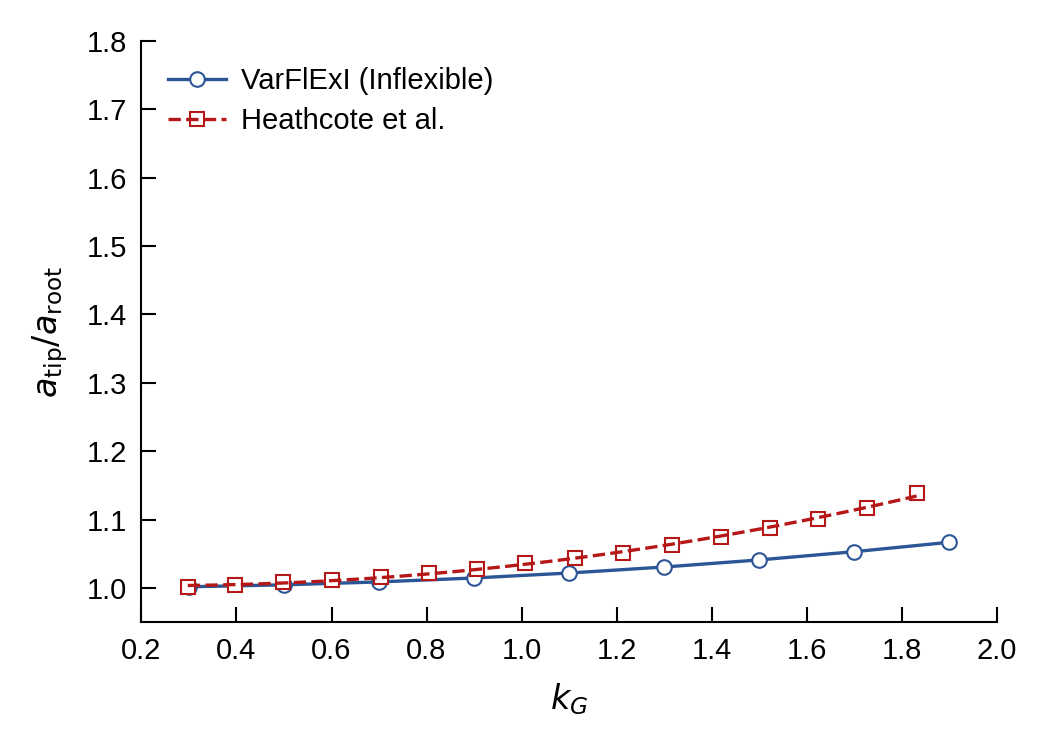

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,            
    "axes.labelsize": 8,       
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,     
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",   
    "ytick.direction": "in",
    "pdf.fonttype": 42,        
    "ps.fonttype": 42
})

# --- Premium Color Palette ---
COLOR_SIM = "#2C5596"  # Deep Charcoal for simulation lines
COLOR_EXP = "#B61717"  # Warm Amber for experimental markers and fit lines

# --- 2. Setup Figure ---
fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

# --- 3. Plotting Simulation Data ---
plot_settings = {
    "inflex": {
        "marker": "o",
        "label": "Inflexible structure, VarFlExI",
        "color": COLOR_SIM,     
    },
}

for structure, settings in plot_settings.items():
    subset = validation_df[
        validation_df["structure"] == structure
    ].sort_values("kG")

    h_sim, = ax.plot(
        subset["kG"],
        subset["amplitude_ratio"],
        color=settings["color"],
        marker=settings["marker"],
        markersize=3.5,         
        linewidth=0.8,          
        markeredgewidth=0.5,
        markerfacecolor="white",
        label=settings["label"],
    )

# --- 4. Load & Plot Experimental Data ---
exp_filepath = "dataset/Fig5(a)_Inflexible.csv"
exp_df = pd.read_csv(exp_filepath, header=None)
exp_df = exp_df.sort_values(by=0)

x_exp = exp_df[0].values
y_exp = exp_df[1].values

# Plot discrete raw points
h_exp_pts, = ax.plot(
    x_exp,
    y_exp,
    color=COLOR_EXP,        
    marker="s",             
    markersize=3.5,
    linewidth=0,            
    linestyle="None",       
    markeredgewidth=0.5,
    markerfacecolor="white",
)

# --- Harmonic Fit Implementation ---
# Harmonic model function reflecting standard sinusoidal extraction: y = A*sin(B*x) + C*cos(B*x) + D
def harmonic_model(x, a, b, c, d):
    return a * np.sin(b * x) + c * np.cos(b * x) + d

h_exp_fit = None
try:
    # Robust initial parameter estimates based on data statistics
    initial_guess = [np.std(y_exp), 1.0, np.std(y_exp), np.mean(y_exp)]
    popt, _ = curve_fit(harmonic_model, x_exp, y_exp, p0=initial_guess, maxfev=10000)
    
    # CRITICAL: Smooth evaluation track limits matched exactly to the dataset domain boundaries
    x_fit = np.linspace(x_exp.min(), x_exp.max(), 500)
    y_fit = harmonic_model(x_fit, *popt)
    
    # Plot smooth harmonic trend curve
    h_exp_fit, = ax.plot(
        x_fit,
        y_fit,
        color=COLOR_EXP,
        linewidth=0.8,
        linestyle="--",
    )
except Exception as e:
    print(f"Harmonic curve fit convergence failed: {e}")

# --- 5. Styling Axes & Unified Legend Arrangement ---
ax.set_xlabel(r"$k_G$")
ax.set_ylabel(r"$a_{\mathrm{tip}}/a_{\mathrm{root}}$")

# Axis padding
ax.set_xlim(0.2, 2.0)
ax.set_ylim(0.95, 1.8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)


legend_handles = [h_sim, (h_exp_pts, h_exp_fit)]
legend_labels = ["VarFlExI (Inflexible)", "Heathcote et al."]


ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    frameon=False, 
    loc="upper left",
    handletextpad=0.5,
    labelspacing=0.4
)

# --- 6. Exporting ---
fig.tight_layout()

# Handle path fallback if FIG_DIR is undefined
fig_dir = Path(FIG_DIR) if 'FIG_DIR' in locals() else Path(".")
fig.savefig(
    fig_dir / "tip_amplitude_vs_reduced_frequency.pdf",
    bbox_inches="tight",
    transparent=True 
)

plt.show()


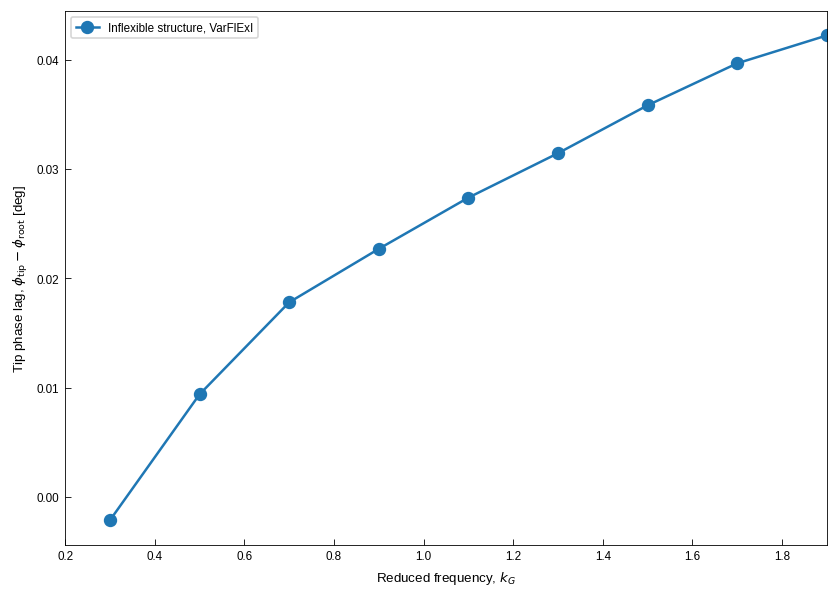

In [21]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)


for structure, settings in plot_settings.items():

    subset = validation_df[
        validation_df["structure"] == structure
    ].sort_values("kG")

    ax.plot(
        subset["kG"],
        subset["phase_difference_deg"],
        marker=settings["marker"],
        markersize=7,
        linewidth=1.5,
        label=settings["label"],
    )


ax.set_xlabel(
    r"Reduced frequency, $k_G$"
)

ax.set_ylabel(
    r"Tip phase lag, $\phi_{\mathrm{tip}}-\phi_{\mathrm{root}}$ [deg]"
)

ax.legend()

ax.set_xlim(0.2, 1.9)

ax.grid(False)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "tip_phase_vs_reduced_frequency.pdf",
    bbox_inches="tight"
)

plt.show()

In [22]:
tipdisp_data = {}

for structure, path in TIPDISP_CASES.items():

    print(
        f"Loading {structure}: "
        f"{path.name}"
    )

    tipdisp_data[structure] = (
        load_displacement(path)
    )

Loading inflex: results_tipdisp_inflex
Loading flex: results_tipdisp_flex
Loading highflex: results_tipdisp_highflex


In [23]:
T_tipdisp = kg_to_period(
    TIPDISP_KG
)

tipdisp_steady = {}


for structure, data in tipdisp_data.items():

    time = data["time"].to_numpy()
    root_z = data["root_z"].to_numpy()
    tip_z = data["tip_z"].to_numpy()

    t_end = time[-1]
    t_start = t_end - 2.0 * T_tipdisp

    mask = time >= t_start

    t_selected = time[mask]

    # Reset nondimensional time to 0
    t_nd = (
        t_selected
        -
        t_selected[0]
    ) / T_tipdisp

    tipdisp_steady[structure] = {
        "t_nd": t_nd,
        "root_z": root_z[mask],
        "tip_z": tip_z[mask],
    }

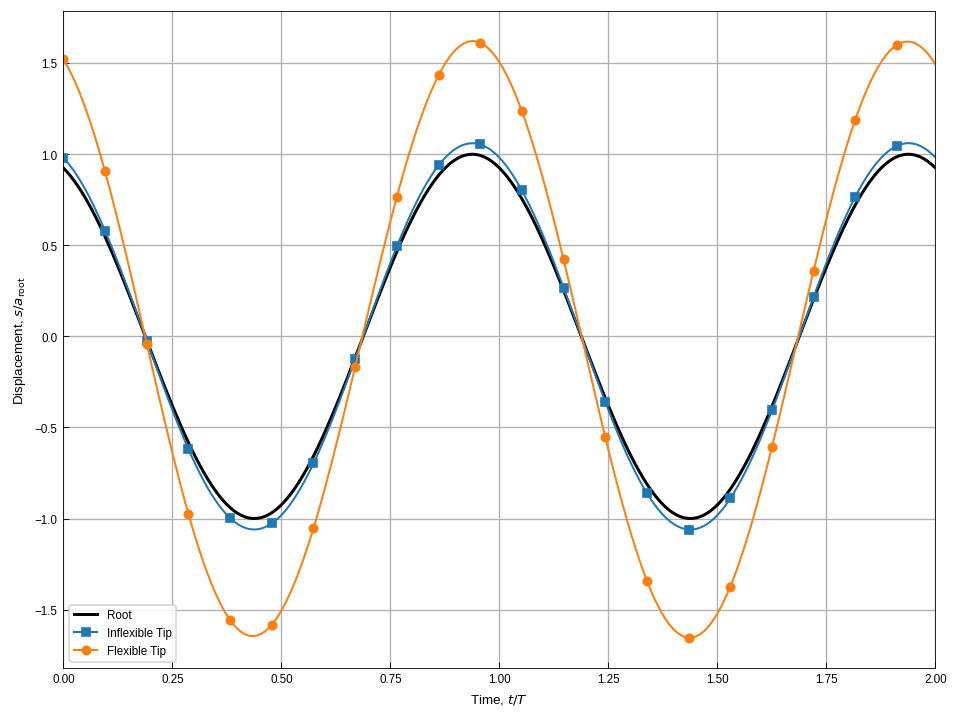

In [24]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

root_data = tipdisp_steady["flex"]

ax.plot(
    root_data["t_nd"],
    root_data["root_z"] / a_root,
    "k-",
    linewidth=1.8,
    label="Root",
)

data = tipdisp_steady["inflex"]

ax.plot(
    data["t_nd"],
    data["tip_z"] / a_root,
    marker="s",
    markevery=max(
        1,
        len(data["t_nd"]) // 20
    ),
    markersize=5,
    linewidth=1.2,
    label="Inflexible Tip",
)

data = tipdisp_steady["flex"]

ax.plot(
    data["t_nd"],
    data["tip_z"] / a_root,
    marker="o",
    markevery=max(
        1,
        len(data["t_nd"]) // 20
    ),
    markersize=5,
    linewidth=1.2,
    label="Flexible Tip",
)

# data = tipdisp_steady["highflex"]

# ax.plot(
#     data["t_nd"],
#     data["tip_z"] / a_root,
#     marker="^",
#     markevery=max(
#         1,
#         len(data["t_nd"]) // 20
#     ),
#     markersize=5,
#     linewidth=1.2,
#     label="Highly Flexible Tip",
# )


ax.set_xlabel(
    r"Time, $t/T$"
)

ax.set_ylabel(
    r"Displacement, $s/a_{\mathrm{root}}$"
)

ax.set_xlim(
    0,
    2
)

ax.legend()

ax.grid(True)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "tip_displacement_kg182_validation.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

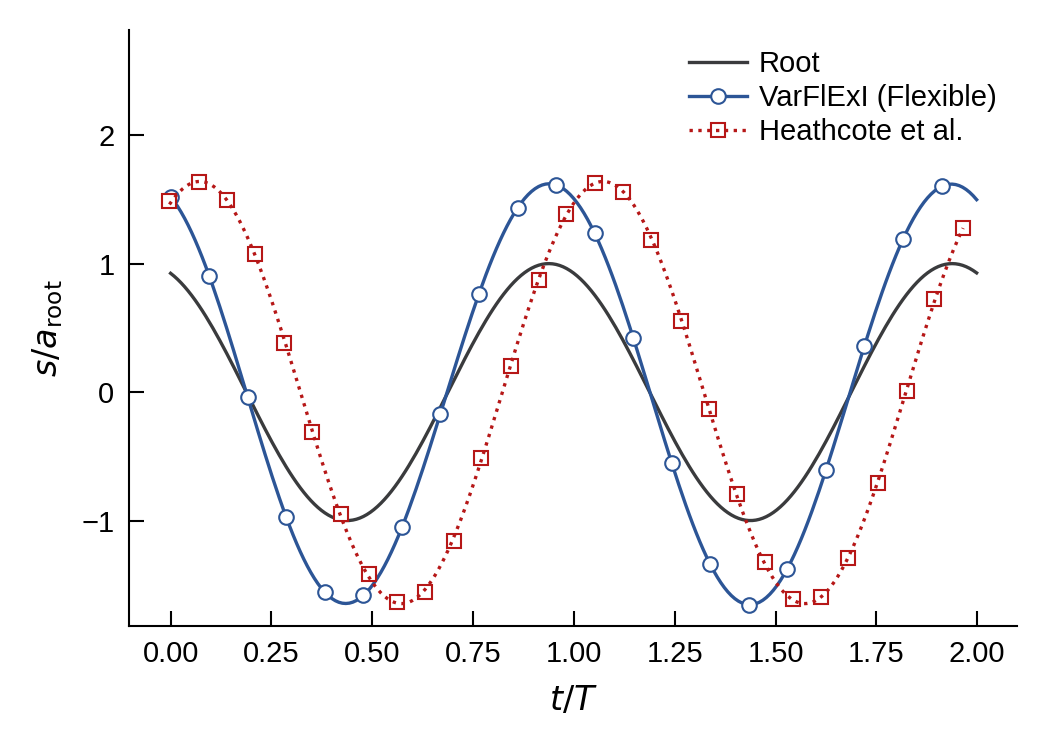

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,            
    "axes.labelsize": 8,       
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,     
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",   
    "ytick.direction": "in",
    "pdf.fonttype": 42,        
    "ps.fonttype": 42
})

# --- Color Palette (Synchronized with previous plots) ---
COLOR_ROOT = "#3A3B3D"  # Analytical slate grey for baseline reference
COLOR_TIP = "#2C5596"   # Deep charcoal/off-black for solver configuration
COLOR_EXP = "#B61717"   # Warm amber/gold for experimental data matching

# --- 2. Setup Figure ---
fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

# --- 3. Plotting Simulation Data ---
root_data = tipdisp_steady["flex"]
h_root, = ax.plot(
    root_data["t_nd"],
    root_data["root_z"] / a_root,
    color=COLOR_ROOT,
    linestyle="-",
    linewidth=0.8,  
    label="Root",
)

data = tipdisp_steady["flex"]
h_sim, = ax.plot(
    data["t_nd"],
    data["tip_z"] / a_root,
    color=COLOR_TIP,
    linestyle="-",
    linewidth=0.8,
    marker="o",
    markevery=max(1, len(data["t_nd"]) // 20),
    markersize=3.5,  
    markeredgewidth=0.5,
    markerfacecolor="white",  
)

# --- 4. Load, Fit, & Plot Experimental Data (No Shift) ---
exp_disp_path = "dataset/Fig4_Flexible.csv"
h_exp_pts = None
h_exp_fit = None

try:
    exp_df = pd.read_csv(exp_disp_path, header=None).sort_values(by=0)
    
    # Native unshifted coordinates
    x_exp = exp_df[0].values
    y_exp = exp_df[1].values
    
    # Plot experimental data points at their original locations
    h_exp_pts, = ax.plot(
        x_exp,
        y_exp,
        color=COLOR_EXP,
        marker="s",
        markersize=3.5,
        linewidth=0,
        linestyle="None",
        markeredgewidth=0.5,
        markerfacecolor="white",
    )

    # Harmonic Fit Function: y = A*sin(B*x) + C*cos(B*x) + D
    def harmonic_model(x, a, b, c, d):
        return a * np.sin(b * x) + c * np.cos(b * x) + d

    initial_guess = [np.std(y_exp), 2 * np.pi, np.std(y_exp), np.mean(y_exp)]
    popt, _ = curve_fit(harmonic_model, x_exp, y_exp, p0=initial_guess, maxfev=10000)
    
    # Generate smooth fitting line strictly over the unshifted dataset domain
    x_fit = np.linspace(x_exp.min(), x_exp.max(), 500)
    y_fit = harmonic_model(x_fit, *popt)
    
    # Plot matching dotted harmonic line
    h_exp_fit, = ax.plot(
        x_fit,
        y_fit,
        color=COLOR_EXP,
        linewidth=0.8,
        linestyle=":",
    )
except Exception as e:
    print(f"Could not load or fit experimental data file: {e}")

# --- 5. Styling Axes & Spine Spacing ---
ax.set_xlabel(r"$t/T$")
ax.set_ylabel(r"$s/a_{\mathrm{root}}$")

# Decreased padding headroom from 0.45 to 0.28 for an optimized, compact layout
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + (y_max - y_min) * 0.28)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# UNIFIED LEGEND ARRANGEMENT
if h_exp_pts is not None and h_exp_fit is not None:
    legend_handles = [h_root, h_sim, (h_exp_pts, h_exp_fit)]
    legend_labels = ["Root", "VarFlExI (Flexible)", "Heathcote et al."]
else:
    legend_handles = None
    legend_labels = None

ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    frameon=False, 
    loc="upper right", 
    handletextpad=0.4,   
    labelspacing=0.2,    
    borderaxespad=0.3
)

# --- 6. Exporting ---
fig.tight_layout()
fig_dir = Path(FIG_DIR) if 'FIG_DIR' in locals() else Path(".")
fig.savefig(
    fig_dir / "tip_displacement_kg182_validation.pdf",
    bbox_inches="tight",
    transparent=True  
)
plt.show()


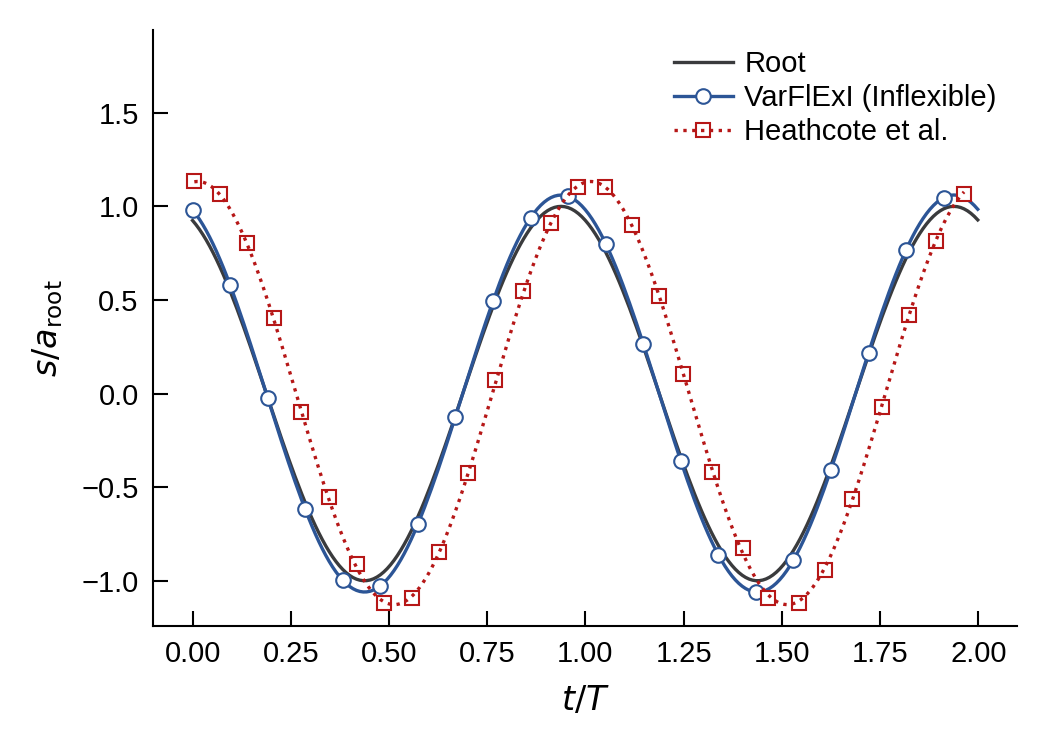

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,            
    "axes.labelsize": 8,       
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,     
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",   
    "ytick.direction": "in",
    "pdf.fonttype": 42,        
    "ps.fonttype": 42
})

# --- Color Palette (Synchronized with previous plots) ---
COLOR_ROOT = "#3A3B3D"  # Analytical slate grey for baseline reference
COLOR_TIP = "#2C5596"   # Deep charcoal/off-black for solver configuration
COLOR_EXP = "#B61717"   # Warm amber/gold for experimental data matching

# --- 2. Setup Figure ---
fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=300)

# --- 3. Plotting Simulation Data ---
root_data = tipdisp_steady["flex"]
h_root, = ax.plot(
    root_data["t_nd"],
    root_data["root_z"] / a_root,
    color=COLOR_ROOT,
    linestyle="-",
    linewidth=0.8,  
    label="Root",
)

data = tipdisp_steady["inflex"]
h_sim, = ax.plot(
    data["t_nd"],
    data["tip_z"] / a_root,
    color=COLOR_TIP,
    linestyle="-",
    linewidth=0.8,
    marker="o",
    markevery=max(1, len(data["t_nd"]) // 20),
    markersize=3.5,  
    markeredgewidth=0.5,
    markerfacecolor="white",  
)

# --- 4. Load, Fit, & Plot Experimental Data (No Shift) ---
exp_disp_path = "dataset/Fig4_Inflexible.csv"
h_exp_pts = None
h_exp_fit = None

try:
    exp_df = pd.read_csv(exp_disp_path, header=None).sort_values(by=0)
    
    # Native unshifted coordinates
    x_exp = exp_df[0].values
    y_exp = exp_df[1].values
    
    # Plot experimental data points at their original locations
    h_exp_pts, = ax.plot(
        x_exp,
        y_exp,
        color=COLOR_EXP,
        marker="s",
        markersize=3.5,
        linewidth=0,
        linestyle="None",
        markeredgewidth=0.5,
        markerfacecolor="white",
    )

    # Harmonic Fit Function: y = A*sin(B*x) + C*cos(B*x) + D
    def harmonic_model(x, a, b, c, d):
        return a * np.sin(b * x) + c * np.cos(b * x) + d

    initial_guess = [np.std(y_exp), 2 * np.pi, np.std(y_exp), np.mean(y_exp)]
    popt, _ = curve_fit(harmonic_model, x_exp, y_exp, p0=initial_guess, maxfev=10000)
    
    # Generate smooth fitting line strictly over the unshifted dataset domain
    x_fit = np.linspace(x_exp.min(), x_exp.max(), 500)
    y_fit = harmonic_model(x_fit, *popt)
    
    # Plot matching dotted harmonic line
    h_exp_fit, = ax.plot(
        x_fit,
        y_fit,
        color=COLOR_EXP,
        linewidth=0.8,
        linestyle=":",
    )
except Exception as e:
    print(f"Could not load or fit experimental data file: {e}")

# --- 5. Styling Axes & Spine Spacing ---
ax.set_xlabel(r"$t/T$")
ax.set_ylabel(r"$s/a_{\mathrm{root}}$")

# Decreased padding headroom from 0.45 to 0.28 for an optimized, compact layout
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + (y_max - y_min) * 0.28)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# UNIFIED LEGEND ARRANGEMENT
if h_exp_pts is not None and h_exp_fit is not None:
    legend_handles = [h_root, h_sim, (h_exp_pts, h_exp_fit)]
    legend_labels = ["Root", "VarFlExI (Inflexible)", "Heathcote et al."]
else:
    legend_handles = None
    legend_labels = None

ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    frameon=False, 
    loc="upper right", 
    handletextpad=0.4,   
    labelspacing=0.2,    
    borderaxespad=0.3
)

# --- 6. Exporting ---
fig.tight_layout()
fig_dir = Path(FIG_DIR) if 'FIG_DIR' in locals() else Path(".")
fig.savefig(
    fig_dir / "tip_displacement_kg182_validation.pdf",
    bbox_inches="tight",
    transparent=True  
)
plt.show()


KeyError: 'highflex'

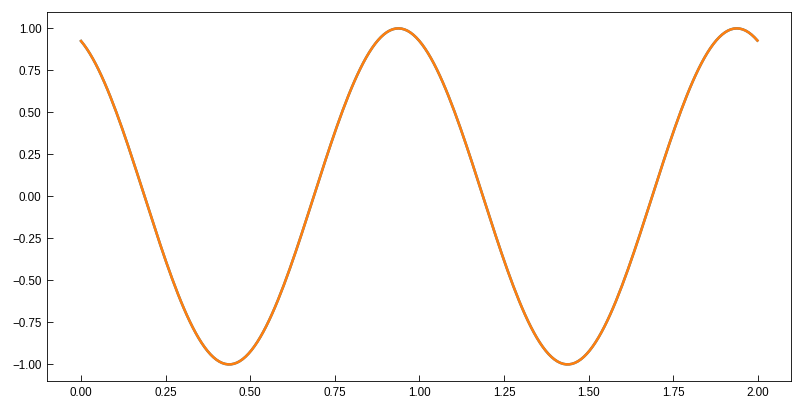

In [27]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

for structure, data in tipdisp_steady.items():

    ax.plot(
        data["t_nd"],
        data["root_z"] / a_root,
        linewidth=1.5,
        label=STRUCTURES[structure],
    )

ax.set_xlabel(
    r"$t/T$"
)

ax.set_ylabel(
    r"$s_{\mathrm{root}}/a_{\mathrm{root}}$"
)

ax.set_xlim(
    0,
    2
)

ax.legend()

ax.grid(True)

fig.tight_layout()

plt.show()

In [ ]:
def plot_harmonic_fit(
    case_dir,
    kG,
    n_cycles=5,
):

    data = load_displacement(
        case_dir
    )

    time = data["time"].to_numpy()
    root = data["root_z"].to_numpy()
    tip = data["tip_z"].to_numpy()

    period = kg_to_period(kG)
    omega = kg_to_omega(kG)

    t_end = time[-1]
    t_start = t_end - n_cycles * period

    mask = time >= t_start

    t = time[mask]
    root = root[mask]
    tip = tip[mask]

    root_fit = harmonic_fit(
        t,
        root,
        omega
    )

    tip_fit = harmonic_fit(
        t,
        tip,
        omega
    )

    t_nd = (
        t - t[0]
    ) / period

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.plot(
        t_nd,
        root,
        label="Root data",
        linewidth=1.5
    )

    ax.plot(
        t_nd,
        root_fit["fitted"],
        "--",
        label="Root harmonic fit",
        linewidth=2
    )

    ax.plot(
        t_nd,
        tip,
        label="Tip data",
        linewidth=1.5
    )

    ax.plot(
        t_nd,
        tip_fit["fitted"],
        "--",
        label="Tip harmonic fit",
        linewidth=2
    )

    ax.set_xlabel(
        r"$t/T$"
    )

    ax.set_ylabel(
        "Displacement [m]"
    )

    ax.legend()

    ax.grid(True)

    fig.tight_layout()

    plt.show()

In [ ]:
summary = validation_df[
    [
        "kG",
        "structure_label",
        "root_amplitude",
        "tip_amplitude",
        "amplitude_ratio",
        "phase_difference_deg",
        "n_cycles_used",
    ]
].copy()

summary.columns = [
    "k_G",
    "Configuration",
    "a_root [m]",
    "a_tip [m]",
    "a_tip/a_root",
    "Phase difference [deg]",
    "Cycles used",
]

display(
    summary.sort_values(
        ["k_G", "Configuration"]
    )
)

In [ ]:
fig, axes = plt.subplots(
    4,
    3,
    figsize=(15, 12),
    sharex=False,
    sharey=False,
)

kg_order = [
    ("KG1", 0.3),
    ("KG2", 0.8),
    ("KG3", 1.3),
    ("KG4", 1.8),
]

structure_order = [
    ("inflex", "Inflexible"),
    ("flex", "Flexible"),
    ("highflex", "Highly Flexible"),
]


for i, (kg_name, kg_value) in enumerate(kg_order):

    T = kg_to_period(kg_value)

    for j, (structure, structure_label) in enumerate(structure_order):

        ax = axes[i, j]

        case_name = f"{kg_name}_{structure}"
        case_dir = SWEEP_CASES[case_name]["path"]

        # Load complete simulation
        data = load_displacement(case_dir)

        time = data["time"].to_numpy()
        tip_z = data["tip_z"].to_numpy()

        # Nondimensional time
        t_nd = time / T

        # Nondimensional displacement
        tip_nd = tip_z / a_root

        ax.plot(
            t_nd,
            tip_nd,
            linewidth=1.0,
        )

        # --------------------------------------------------
        # Show where the final 5-cycle fitting window starts
        # --------------------------------------------------

        n_fit_cycles = 5

        total_cycles = (
            time[-1] - time[0]
        ) / T

        n_use = min(
            n_fit_cycles,
            int(np.floor(total_cycles))
        )

        if n_use >= 1:

            t_fit_start = (
                time[-1]
                -
                n_use * T
            )

            t_fit_start_nd = (
                t_fit_start / T
            )

            ax.axvline(
                t_fit_start_nd,
                linestyle="--",
                linewidth=1.2,
                label="Fit window start"
                if (i == 0 and j == 0)
                else None,
            )

        # --------------------------------------------------
        # Labels
        # --------------------------------------------------

        ax.set_title(
            f"{structure_label}, "
            rf"$k_G={kg_value}$"
        )

        ax.set_xlabel(
            r"Time, $t/T$"
        )

        ax.set_ylabel(
            r"$s_{\mathrm{tip}}/a_{\mathrm{root}}$"
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        # Number of simulated cycles
        ax.text(
            0.02,
            0.95,
            f"Total cycles = {total_cycles:.1f}",
            transform=ax.transAxes,
            verticalalignment="top",
            fontsize=9,
        )


fig.suptitle(
    "Complete Tip-Displacement Histories — Transient Check",
    fontsize=15,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "all_cases_tip_displacement_transient_check.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()